# StreamNow — Subscription Churn Prediction
## DSAI Mini Coursework

**Student name**: *(fill in)*  
**Email**: *(fill in)*  
**Discord username**: *(fill in)*  
**Submission date**: *(fill in)*

---

### Mark Scheme

| Section | Topic | Marks |
|---|---|---|
| 1 | Understanding the Problem | 10 |
| 2 | Setup & Data Loading | 3 |
| 3 | Exploring the Data (EDA) | 10 |
| 4 | Cleaning & Joining the Data | 12 |
| 5 | Creating New Features | 15 |
| 6 | Training Models | 15 |
| 7 | Evaluating Your Model | 8 |
| 8 | Business Impact | 12 |
| 9 | Monitoring for Drift in Production | 5 |
| Extension | Extension Tasks | 10 |
| **Total** | | **100** |

---
# SECTION 1 — Understanding the Problem *(10 marks)*

**1.1** *(1 mark)* In one sentence, describe what StreamNow is trying to predict and why it matters to the business.

StreamNow is trying to predict which subscribers are likely to churn (cancel their subscription) so that the Retention Team can intervene proactively, reducing the loss of recurring revenue for the business.

---

**1.2** *(2 marks)* Is this a classification or regression problem? What is the target variable? What does one row in the training data represent?

This is a binary classification problem, since the target variable only takes two values: churned or not churned. The target variable is `churned_30d`, which indicates whether a subscriber cancelled their subscription within 30 days after the snapshot date. One row in the training data represents a single subscriber as of the snapshot date.

---

**1.3** *(3 marks)* Only ~5.8% of subscribers churn each month. Explain why **accuracy** is a poor metric for this problem. What metric will you use instead, and what does it measure?

Accuracy should not be used because the dataset is imbalanced only about 5.8% of subscribers churn, while 94.2% remain subscribed. If the model simply predicted "no churn" for every subscriber, accuracy would still be around 94.2%, yet the model would fail to identify any at-risk customers at all. Instead, ROC-AUC is used to evaluate the model, since this metric measures the model's ability to distinguish between subscribers who will churn and those who won't, across many different decision thresholds.

---

**1.4** *(2 marks)* The Retention Team can contact only the top **20%** highest-risk subscribers each month. Describe the two types of mistake your model can make, and explain which is more costly to the business at this contact rate.

The model can make two types of mistake:
- **False Negative:** a subscriber who will actually churn is predicted as low-risk (not in the top 20%), so they are never contacted and the company loses that customer entirely.
- **False Positive:** a subscriber who was never going to churn is predicted as high-risk (placed in the top 20%), so the Retention Team spends contact effort/incentives on a customer who was already going to stay.

At this contact rate, **False Negatives are more costly**, because with a limited contact budget, every missed at risk subscriber represents a permanent loss of recurring revenue (customer lifetime value), which is far more expensive than the relatively small cost of a wasted retention offer to a loyal customer (False Positive).

---

**1.5** *(2 marks)* The `viewing_history` table has one row per viewing session, but the model needs one row per subscriber. Explain why you cannot join this table directly to `subscribers`, and what step is required first.

The two tables have different grains: each row in `subscribers` represents one customer, while each row in `viewing_history` represents one viewing session, and a single subscriber can have many sessions. Joining directly on `subscriber_id` would duplicate each subscriber into multiple rows (one per session), breaking the "one row per subscriber" structure the model needs and duplicating the `churned_30d` label across all of that subscriber's rows. The required step first is to aggregate `viewing_history` by `subscriber_id`, computing summary features of each subscriber's viewing behaviour (e.g. total sessions, total watch time, average session length, days since last session). Only after this aggregation which produces exactly one row per subscriber can the table be safely joined to `subscribers`.

---
# SECTION 2 — Setup & Data Loading *(3 marks)*

In [2]:
# *(1 mark)* Import all libraries you will need.
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
SNAPSHOT = pd.Timestamp('2026-06-20')

In [3]:
# *(2 marks)* Load all four CSV files. Print the shape and first few rows of each.
subscribers   = pd.read_csv('data/subscribers.csv',    parse_dates=['signup_date'])
viewing       = pd.read_csv('data/viewing_history.csv', parse_dates=['session_date'])
tickets       = pd.read_csv('data/support_tickets.csv', parse_dates=['ticket_date'])
billing       = pd.read_csv('data/billing.csv',         parse_dates=['billing_date'])

In [4]:
from IPython.display import display

datasets = {
    "Subscribers": subscribers,
    "Viewing History": viewing,
    "Support Tickets": tickets,
    "Billing": billing
}

for name, df in datasets.items():
    print("=" * 60)
    print(name)
    print(f"Shape: {df.shape}")
    display(df.head())

Subscribers
Shape: (8030, 9)


,subscriber_id,signup_date,plan,payment_method,age,gender,country,device_primary,churned_30d
0,S000001,2025-01-18,premium,credit_card,NaN,M,UK,mobile,0
1,S000002,2024-10-18,standard,credit_card,53.0,NaN,UK,tv,0
2,S000003,2026-05-21,premium,debit_card,16.0,F,UK,laptop,0
3,S000004,2024-12-18,standard,credit_card,64.0,F,UK,tv,0
4,S000005,2025-08-19,basic,paypal,36.0,F,UK,laptop,0


Viewing History
Shape: (92196, 7)


,session_id,subscriber_id,session_date,duration_mins,content_type,completed,device
0,V00000001,S000001,2026-03-23,80.5,series,0,mobile
1,V00000002,S000001,2026-03-25,66.3,series,1,mobile
2,V00000003,S000001,2026-03-29,36.8,series,0,tv
3,V00000004,S000001,2026-03-31,47.7,series,0,tv
4,V00000005,S000001,2026-04-05,40.0,movie,0,mobile


Support Tickets
Shape: (9978, 6)


,ticket_id,subscriber_id,ticket_date,category,resolved,resolution_days
0,T0000001,S000001,2026-02-10,technical,1,0.5
1,T0000002,S000002,2025-12-27,content,1,3.7
2,T0000003,S000003,2026-01-09,cancellation_intent,0,NaN
3,T0000004,S000003,2026-05-29,technical,1,1.0
4,T0000005,S000004,2026-02-08,billing,1,11.0


Billing
Shape: (72219, 6)


,billing_id,subscriber_id,billing_date,amount_due,payment_status,retry_count
0,B00000001,S000001,2025-07-05,17.99,paid,0
1,B00000002,S000001,2025-08-04,17.99,paid,0
2,B00000003,S000001,2025-09-04,17.99,paid,0
3,B00000004,S000001,2025-10-04,17.99,paid,0
4,B00000005,S000001,2025-11-04,17.99,disputed,3


---
# SECTION 3 — Exploring the Data (EDA) *(15 marks)*

### 3.1 Data Quality Check *(4 marks)*

In [25]:
# *(4 marks)* For each table, check:
# - Schema (dtypes, null counts, unique values)
# - Duplicate rows
# - Referential integrity (are all subscriber_ids in viewing/tickets/billing present in subscribers?)
# - Class balance (what % of subscribers churned?)

# Your code here
# *(4 marks)* For each table, check:
# - Schema (dtypes, null counts, unique values)
# - Duplicate rows
# - Referential integrity (are all subscriber_ids in viewing/tickets/billing present in subscribers?)
# - Class balance (what % of subscribers churned?)
# Check schema, null counts, unique values, and duplicates for each table

In [7]:
tables = {
    'subscribers': (subscribers, 'subscriber_id'),
    'viewing':     (viewing,     'session_id'),
    'tickets':     (tickets,     'ticket_id'),
    'billing':     (billing,     'billing_id'),
}

# 1. Dtypes, null counts, duplicate rows for each table
for name, (df, key) in tables.items():
    print(f"=== {name} ({df.shape[0]:,} rows, {df.shape[1]} cols) ===")
    print(df.dtypes.to_string())
    null_counts = df.isnull().sum()
    null_counts = null_counts[null_counts > 0]
    print("Missing values:" if len(null_counts) else "Missing values: none")
    if len(null_counts):
        print(null_counts.to_string())
    print(f"Fully duplicated rows: {df.duplicated().sum()}")
    print(f"Duplicate rows by key '{key}': {df[key].duplicated().sum()}")
    print()

=== subscribers (8,030 rows, 9 cols) ===
subscriber_id             object
signup_date       datetime64[ns]
plan                      object
payment_method            object
age                      float64
gender                    object
country                   object
device_primary            object
churned_30d                int64
Missing values:
age       264
gender    325
Fully duplicated rows: 30
Duplicate rows by key 'subscriber_id': 30

=== viewing (92,196 rows, 7 cols) ===
session_id               object
subscriber_id            object
session_date     datetime64[ns]
duration_mins           float64
content_type             object
completed                 int64
device                   object
Missing values: none
Fully duplicated rows: 0
Duplicate rows by key 'session_id': 0

=== tickets (9,978 rows, 6 cols) ===
ticket_id                  object
subscriber_id              object
ticket_date        datetime64[ns]
category                   object
resolved                    i

In [8]:
# 2. Referential integrity — "orphaned" subscriber_id (not present in subscribers)
subscriber_id_set = set(subscribers['subscriber_id'])
for name in ['viewing', 'tickets', 'billing']:
    df = tables[name][0]
    orphaned = (~df['subscriber_id'].isin(subscriber_id_set)).sum()
    print(f"{name}: rows with subscriber_id not present in subscribers = {orphaned}")

active_set = (set(viewing['subscriber_id']) | set(tickets['subscriber_id'])
              | set(billing['subscriber_id']))
print(f"Subscribers with no rows at all in viewing/tickets/billing: "
      f"{len(subscriber_id_set - active_set)}")
print()

viewing: rows with subscriber_id not present in subscribers = 0
tickets: rows with subscriber_id not present in subscribers = 0
billing: rows with subscriber_id not present in subscribers = 0
Subscribers with no rows at all in viewing/tickets/billing: 0



In [9]:
# 3. Date sanity checks — activity before signup or after the snapshot date
for name, date_col in [('viewing', 'session_date'), ('tickets', 'ticket_date'), ('billing', 'billing_date')]:
    df = tables[name][0]
    merged = df.merge(subscribers[['subscriber_id', 'signup_date']], on='subscriber_id')
    before_signup = (merged[date_col] < merged['signup_date']).sum()
    after_snapshot = (df[date_col] > SNAPSHOT).sum()
    print(f"{name}: {before_signup} rows dated before signup_date | "
          f"{after_snapshot} rows dated after the snapshot | "
          f"date range {df[date_col].min().date()} to {df[date_col].max().date()}")
print()

viewing: 4295 rows dated before signup_date | 0 rows dated after the snapshot | date range 2026-03-23 to 2026-06-19
tickets: 2034 rows dated before signup_date | 0 rows dated after the snapshot | date range 2025-12-22 to 2026-06-19
billing: 0 rows dated before signup_date | 0 rows dated after the snapshot | date range 2025-07-05 to 2026-06-05



In [10]:
# 4. Sanity check of value ranges
print(f"age range: {subscribers['age'].min()} to {subscribers['age'].max()}")
print(f"duration_mins range: {viewing['duration_mins'].min()} to {viewing['duration_mins'].max()}")
print(f"amount_due range: {billing['amount_due'].min()} to {billing['amount_due'].max()}")
print()

age range: 16.0 to 73.0
duration_mins range: 2.0 to 240.0
amount_due range: 6.99 to 17.99



In [11]:
# 5. Kiểm tra giá trị categorical có khớp với data dictionary không
for cot in ['plan', 'payment_method', 'gender', 'country', 'device_primary']:
    print(f"subscribers.{cot}: {sorted(subscribers[cot].dropna().unique())}")
print(f"viewing.content_type: {sorted(viewing['content_type'].unique())}")
print(f"viewing.device: {sorted(viewing['device'].unique())}")
print(f"tickets.category: {sorted(tickets['category'].unique())}")
print(f"billing.payment_status: {sorted(billing['payment_status'].unique())}")
print()

subscribers.plan: ['basic', 'premium', 'standard']
subscribers.payment_method: ['credit_card', 'debit_card', 'paypal', 'voucher']
subscribers.gender: ['F', 'M', 'other']
subscribers.country: ['IE', 'UK']
subscribers.device_primary: ['laptop', 'mobile', 'tablet', 'tv']
viewing.content_type: ['documentary', 'kids', 'movie', 'series', 'sport']
viewing.device: ['laptop', 'mobile', 'tablet', 'tv']
tickets.category: ['billing', 'cancellation_intent', 'content', 'other', 'technical']
billing.payment_status: ['disputed', 'failed', 'paid']



In [12]:
# 6. Target variable class balance
churn_rate = subscribers['churned_30d'].mean()
print(f"Churn rate (churned_30d == 1): {churn_rate:.2%}")
print(subscribers['churned_30d'].value_counts())
print()

# 7. Activity volume per subscriber (outlier detection)
print("Number of viewing sessions per subscriber (subscribers with >= 1 session):")
print(viewing.groupby('subscriber_id').size().describe())

Churn rate (churned_30d == 1): 5.67%
churned_30d
0    7575
1     455
Name: count, dtype: int64

Number of viewing sessions per subscriber (subscribers with >= 1 session):
count    7997.000000
mean       11.528823
std         5.522257
min         1.000000
25%         7.000000
50%        11.000000
75%        15.000000
max        37.000000
dtype: float64


**Commentary** — List the data quality issues you found and how you will handle each.

The `subscribers` table has 30 duplicate records (including duplicated `subscriber_id`). These will be removed (keeping the first occurrence), ensuring each subscriber appears exactly once.

No missing values were found in `viewing_history`, and there are no referential integrity issues between the related tables, so no further handling is needed for this part.

There are 4,266 viewing sessions and 2,015 support tickets dated before the corresponding subscriber's `signup_date` (counted after removing the 30 duplicate rows in `subscribers`). This is not logically valid — a subscriber cannot watch content or raise a support ticket before they existed in the system, so these are treated as erroneous records. These rows will be removed before feature aggregation in Section 4, so that only activity occurring after signup is used, avoiding distortion of features such as `total_sessions_90d` or `total_tickets`.

`resolution_days` is missing for 3,328/9,978 records — this is a meaningful missing value (the ticket has not yet been resolved), which is fundamentally different in nature from the missingness in `age`/`gender` (missing due to data entry errors or genuinely unrecorded information). Therefore it will not be imputed with the median like `age`; instead it will be kept as NaN or handled separately (sentinel/flag) at the feature engineering stage.

### 3.2 Distribution of Each Column *(3 marks)*

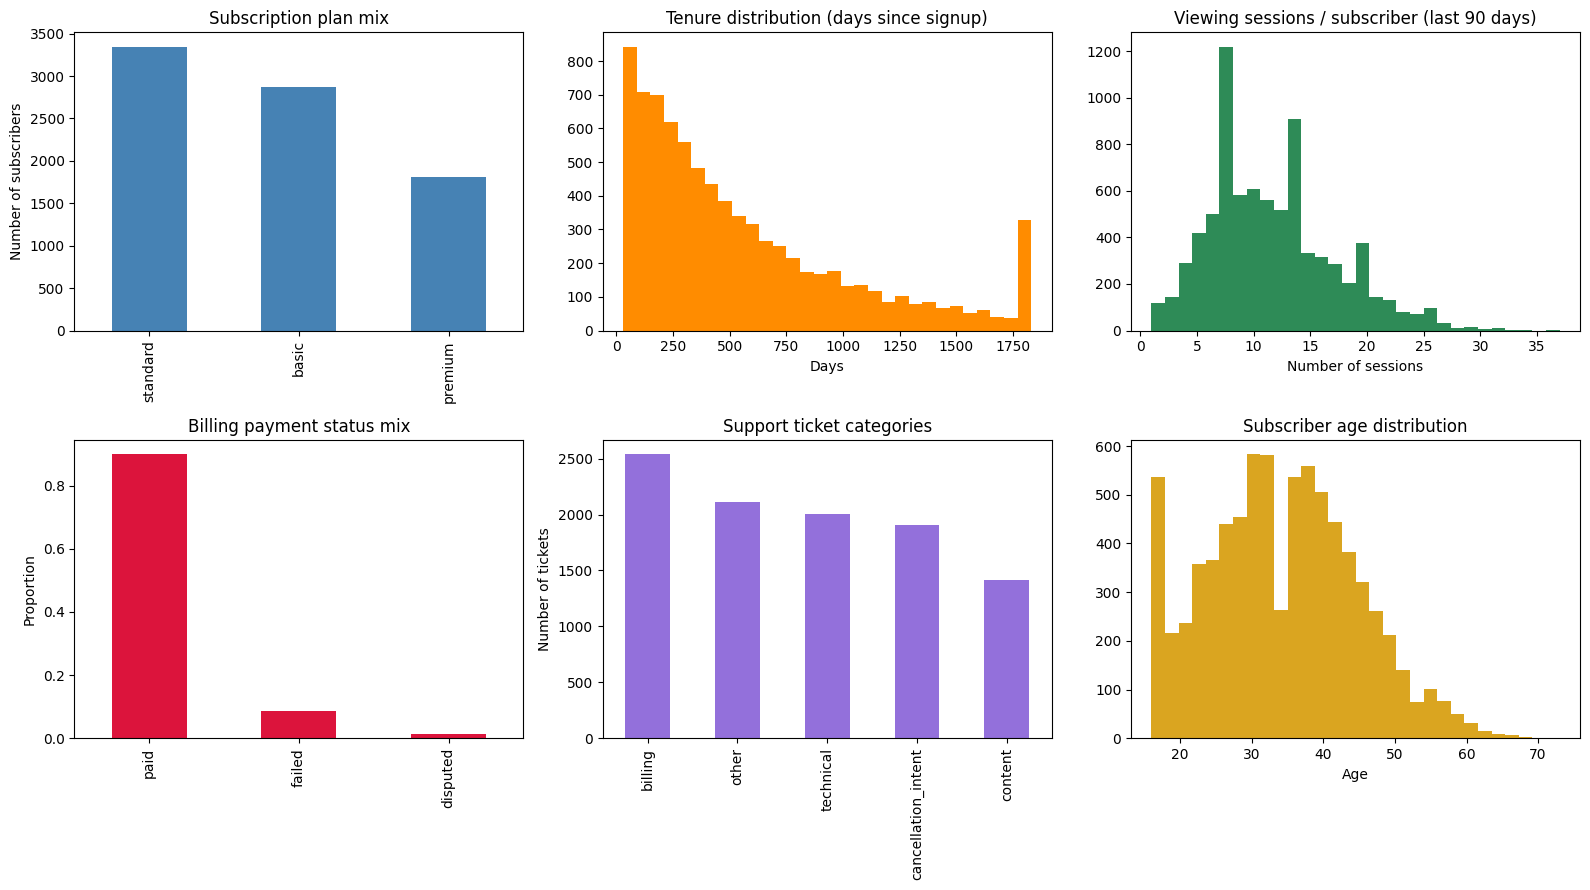

Tenure (days) — summary statistics:
count    8030.000000
mean      548.850311
std       482.583307
min        30.000000
25%       183.000000
50%       396.000000
75%       793.000000
max      1830.000000
Name: signup_date, dtype: float64

Failed/disputed payment rate: 10.09%


In [13]:
# *(3 marks)* Plot distributions of key numeric and categorical columns.
# At minimum: plan mix, tenure distribution, viewing session count per subscriber,
# billing failure rate, support ticket categories.

# Your code here


tenure_days = (SNAPSHOT - subscribers['signup_date']).dt.days

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# 1. Plan mix
subscribers['plan'].value_counts().plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Subscription plan mix')
axes[0, 0].set_xlabel('')
axes[0, 0].set_ylabel('Number of subscribers')

# 2. Tenure distribution
axes[0, 1].hist(tenure_days, bins=30, color='darkorange')
axes[0, 1].set_title('Tenure distribution (days since signup)')
axes[0, 1].set_xlabel('Days')

# 3. Viewing sessions per subscriber
sessions_per_sub = viewing.groupby('subscriber_id').size()
axes[0, 2].hist(sessions_per_sub, bins=30, color='seagreen')
axes[0, 2].set_title('Viewing sessions / subscriber (last 90 days)')
axes[0, 2].set_xlabel('Number of sessions')

# 4. Payment status mix (paid / failed / disputed)
billing['payment_status'].value_counts(normalize=True).plot(
    kind='bar', ax=axes[1, 0], color='crimson')
axes[1, 0].set_title('Billing payment status mix')
axes[1, 0].set_ylabel('Proportion')
axes[1, 0].set_xlabel('')

# 5. Support ticket categories
tickets['category'].value_counts().plot(kind='bar', ax=axes[1, 1], color='mediumpurple')
axes[1, 1].set_title('Support ticket categories')
axes[1, 1].set_xlabel('')
axes[1, 1].set_ylabel('Number of tickets')

# 6. Subscriber age distribution
axes[1, 2].hist(subscribers['age'].dropna(), bins=30, color='goldenrod')
axes[1, 2].set_title('Subscriber age distribution')
axes[1, 2].set_xlabel('Age')

plt.tight_layout()
plt.show()

print("Tenure (days) — summary statistics:")
print(tenure_days.describe())
print()
print("Failed/disputed payment rate:",
      f"{(billing['payment_status'] != 'paid').mean():.2%}")

**Commentary** — What did you notice? Mention at least two interesting observations.

Tenure shows an unusually tall spike right at the maximum value (~1750-1830 days), clearly separated from the gradually declining tail before it. This does not look like a natural distribution it is likely a "left-censoring" effect: there was a specific service launch date, and every subscriber who signed up from day one is pushed to exactly the same maximum tenure value, forming a distinct spike instead of a smooth tail.

The distribution of session counts has 3 distinct peaks (~7, ~13, ~20) instead of one smooth peak this is a sign of several mixed behavioural segments in the same chart, rather than random noise. This is likely related to viewing frequency varying by content type or subscription plan.

Billing-related tickets are the most common category (~2500), even more than technical issues for a streaming platform, one would typically expect technical problems (buffering, app errors...) to be the largest source of tickets, yet billing tops the list here. This suggests payment friction is a notable operational issue for StreamNow.

### 3.3 Which Columns are Related to Churn? *(5 marks)*

In [ ]:
# *(5 marks)* Explore the relationship between churn and:
# - Plan type
# - Tenure (how long they've been a subscriber)
# - Viewing activity (e.g. sessions in last 30 days)
# - Payment failures
# Use bar charts, KDE plots, or box plots as appropriate.

# Your code here

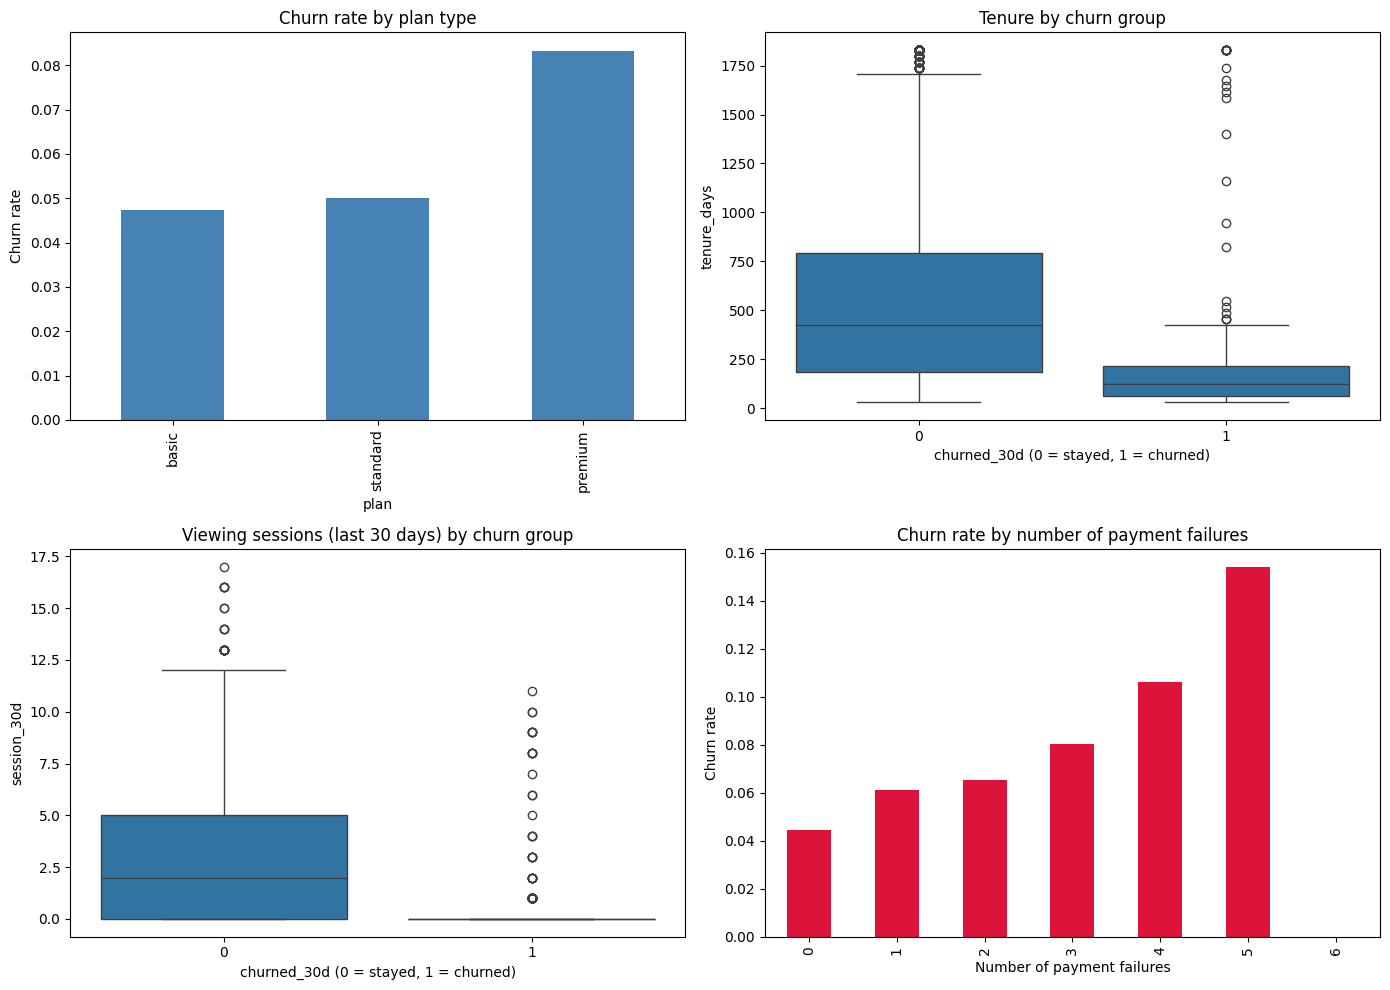

Churn rate by plan:
 plan
basic       0.047403
standard    0.050179
premium     0.083287
Name: churned_30d, dtype: float64

Median tenure — churn=0 vs churn=1:
churned_30d
0    427.0
1    122.0
Name: tenure_days, dtype: float64

Median sessions (30 days) — churn=0 vs churn=1:
churned_30d
0    2.0
1    0.0
Name: session_30d, dtype: float64


In [14]:

tenure_days = (SNAPSHOT - subscribers['signup_date']).dt.days

# sessions in the last 30 days / subscriber
recent_cutoff = SNAPSHOT - pd.Timedelta(days=30)
session_30d = (
    viewing[viewing['session_date'] >= recent_cutoff]
    .groupby('subscriber_id').size()
    .reindex(subscribers['subscriber_id'], fill_value=0)
)

# number of failed (failed/disputed) payments / subscriber
fail_count = (
    billing[billing['payment_status'] != 'paid']
    .groupby('subscriber_id').size()
    .reindex(subscribers['subscriber_id'], fill_value=0)
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Churn by plan
churn_by_plan = subscribers.groupby('plan')['churned_30d'].mean().sort_values()
churn_by_plan.plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Churn rate by plan type')
axes[0, 0].set_ylabel('Churn rate')

# 2. Tenure: distribution comparison between churn and non-churn groups (box plot)
tenure_df = pd.DataFrame({'tenure_days': tenure_days, 'churned_30d': subscribers['churned_30d']})
sns.boxplot(data=tenure_df, x='churned_30d', y='tenure_days', ax=axes[0, 1])
axes[0, 1].set_title('Tenure by churn group')
axes[0, 1].set_xlabel('churned_30d (0 = stayed, 1 = churned)')

# 3. Recent viewing activity (30 days) by churn group
session_df = pd.DataFrame({'session_30d': session_30d.values, 'churned_30d': subscribers['churned_30d'].values})
sns.boxplot(data=session_df, x='churned_30d', y='session_30d', ax=axes[1, 0])
axes[1, 0].set_title('Viewing sessions (last 30 days) by churn group')
axes[1, 0].set_xlabel('churned_30d (0 = stayed, 1 = churned)')

# 4. Payment failures by churn group
fail_df = pd.DataFrame({'fail_count': fail_count.values, 'churned_30d': subscribers['churned_30d'].values})
churn_rate_by_fail = fail_df.groupby('fail_count')['churned_30d'].mean()
churn_rate_by_fail.plot(kind='bar', ax=axes[1, 1], color='crimson')
axes[1, 1].set_title('Churn rate by number of payment failures')
axes[1, 1].set_xlabel('Number of payment failures')
axes[1, 1].set_ylabel('Churn rate')

plt.tight_layout()
plt.show()

# Summary numbers to support the Commentary
print("Churn rate by plan:\n", churn_by_plan)
print()
print("Median tenure — churn=0 vs churn=1:")
print(tenure_df.groupby('churned_30d')['tenure_days'].median())
print()
print("Median sessions (30 days) — churn=0 vs churn=1:")
print(session_df.groupby('churned_30d')['session_30d'].median())

**Commentary** — Which columns show the strongest relationship with churn?

1. Number of payment failures the strongest relationship

The chart shows a clear, monotonic dose-response relationship: the churn rate rises almost linearly from ~4.4% (0 failures) up to ~15.3% (5 failures)  more than a 3x increase. This is the strongest and most consistent signal among the 4 variables, with no noise or exceptions.

2. Tenure a very strong relationship

The median tenure of the churned group is only 122 days, compared to 427 days for the non churned group a difference of more than 3.5x. The box plot also shows the churn group (right) concentrated heavily in the low tenure region, with a much narrower spread than the non churn group.

3. Recent viewing activity (30-day sessions)  a very strong relationship

The median session count for the churned group is nearly 0, versus 2 for the non churned group. The right hand box plot is almost "pressed against zero", with many outliers above showing that most subscribers about to churn had essentially stopped using the service before officially cancelling.

4. Plan type the weakest relationship

Premium has the highest churn rate (8.3%) compared to basic/standard (~4.7-5.0%), but the absolute difference is only about 3-4 percentage points  much smaller than the three variables above.

Overall, churn here is driven mainly by a subscriber's recent behaviour, not by the plan they originally chose.

### 3.4 Which Subscriber Segments Churn Most? *(3 marks)*

In [ ]:
# *(3 marks)* Compute churn rate by: plan, device_primary, payment_method, country.
# Visualise with horizontal bar charts ordered by churn rate.

# Your code here

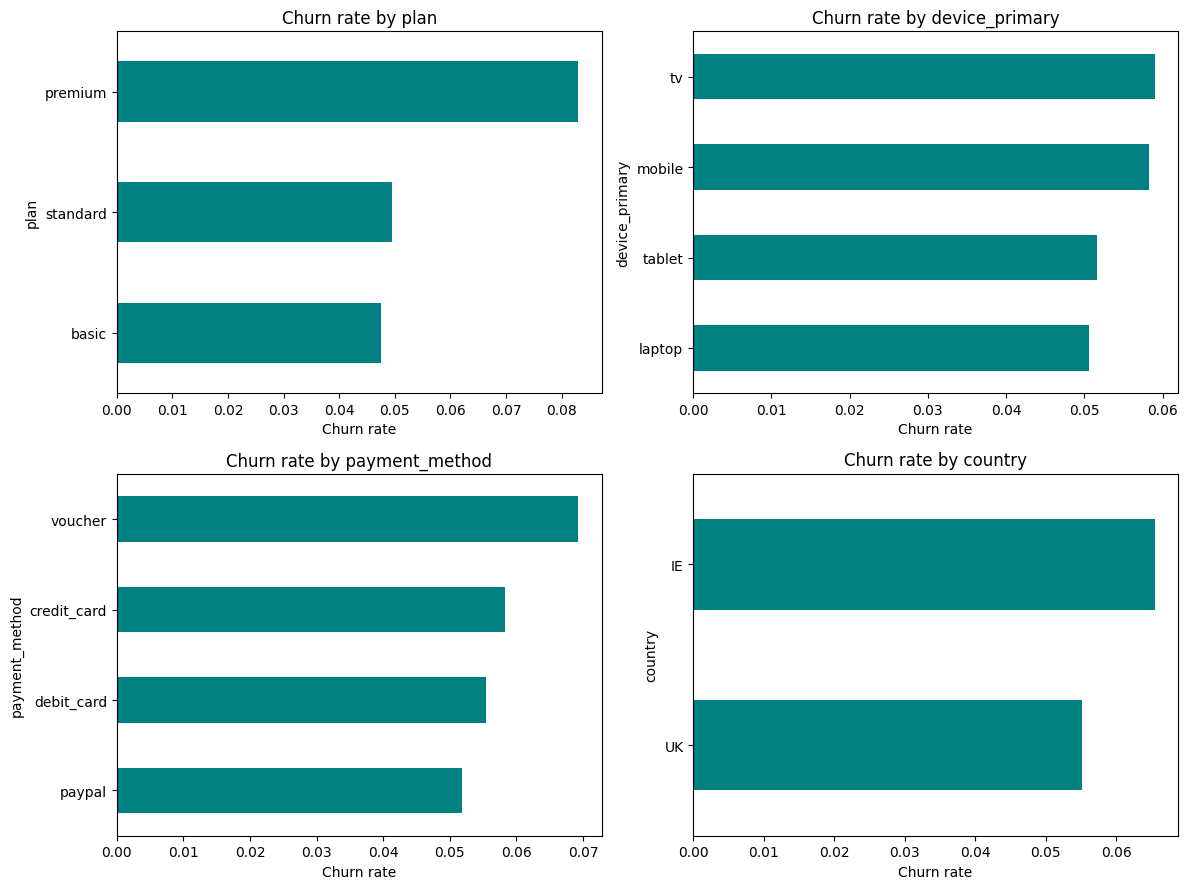

--- Churn rate by plan ---
plan
premium     0.083056
standard    0.049520
basic       0.047519
Name: churned_30d, dtype: float64

--- Churn rate by device_primary ---
device_primary
tv        0.058979
mobile    0.058226
tablet    0.051613
laptop    0.050600
Name: churned_30d, dtype: float64

--- Churn rate by payment_method ---
payment_method
voucher        0.069333
credit_card    0.058281
debit_card     0.055437
paypal         0.051860
Name: churned_30d, dtype: float64

--- Churn rate by country ---
country
IE    0.065440
UK    0.055113
Name: churned_30d, dtype: float64



In [66]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
cols = ['plan', 'device_primary', 'payment_method', 'country']

for ax, col in zip(axes.ravel(), cols):
    rate = subscribers.groupby(col)['churned_30d'].mean().sort_values()
    rate.plot(kind='barh', ax=ax, color='teal')
    ax.set_title(f'Churn rate by {col}')
    ax.set_xlabel('Churn rate')

plt.tight_layout()
plt.show()

for col in cols:
    print(f"--- Churn rate by {col} ---")
    print(subscribers.groupby(col)['churned_30d'].mean().sort_values(ascending=False))
    print()

**Commentary** — Which two segments have the highest churn rates? What is the business implication?

Looking across the four charts, the two segments with the highest churn rates (by absolute value, compared across all four variables) are:
1. Premium (8.33%) the highest of any segment across all four variables
2. Voucher (7.16%) the second highest, well above the other three payment methods

Business implications:

Premium has the highest churn despite being the highest-paying tier this is concerning because this segment generates the highest revenue per subscriber (£17.99 x margin). Losing a Premium subscriber causes far more financial damage than losing a Basic subscriber. This may be because Premium creates higher expectations (more features/content), so if those expectations aren't met, customers are more likely to be disappointed and cancel.

Mitigation: the Retention Team should prioritise closer monitoring and care for the Premium segment, given both the high risk and the high value at stake.

Voucher has the highest churn among payment methods this segment is typically made up of customers using promo codes/trials, who may have less real financial "commitment" to the service (no long-term binding payment method like credit_card/debit_card). When the voucher or promotion expires, they are more likely to leave.

Mitigation: a strategy is needed to convert voucher customers to a recurring payment method before their promotion expires.

---
# SECTION 4 — Cleaning & Joining the Data *(12 marks)*

In [15]:
# *(3 marks)* 4.1 — Deduplication
# Remove duplicate rows from subscribers. Keep the first occurrence.

# Your code here
print(f"Row count before deduplication: {len(subscribers):,}")
subscribers = subscribers.drop_duplicates(subset='subscriber_id', keep='first').reset_index(drop=True)
print(f"Row count after deduplication: {len(subscribers):,}")

Row count before deduplication: 8,030
Row count after deduplication: 8,000


In [16]:
median_age = subscribers['age'].median()
mode_gender = subscribers['gender'].mode()[0]

subscribers['age'] = subscribers['age'].fillna(median_age)
subscribers['gender'] = subscribers['gender'].fillna(mode_gender)

In [19]:
# *(5 marks)* 4.2 — Aggregate viewing_history to one row per subscriber.
# Compute at minimum:
# - Total sessions and total watch time in the last 90 days
# - Days since last session
# - Completion rate (fraction of sessions where completed=1)
# - Viewing trend: watch time in last 30 days vs prior 30 days

# Your code here

viewing_valid = viewing.merge(subscribers[['subscriber_id', 'signup_date']], on='subscriber_id')
rows_removed = (viewing_valid['session_date'] < viewing_valid['signup_date']).sum()
viewing_valid = viewing_valid[viewing_valid['session_date'] >= viewing_valid['signup_date']].drop(columns='signup_date')
print(f"Removed {rows_removed} viewing rows with session_date before signup_date "
      f"({rows_removed / len(viewing):.1%} of all rows)")

cutoff_30 = SNAPSHOT - pd.Timedelta(days=30)
cutoff_60 = SNAPSHOT - pd.Timedelta(days=60)

# Basic aggregation: session count, total watch minutes, completion rate, last viewing date
# using the filtered viewing_valid, instead of the raw viewing table
viewing_agg = viewing_valid.groupby('subscriber_id').agg(
    total_sessions_90d=('session_id', 'count'),
    total_watch_mins_90d=('duration_mins', 'sum'),
    completion_rate=('completed', 'mean'),
    last_session_date=('session_date', 'max'),
).reset_index()

viewing_agg['days_since_last_session'] = (SNAPSHOT - viewing_agg['last_session_date']).dt.days
viewing_agg = viewing_agg.drop(columns='last_session_date')

# Viewing trend: watch minutes in the last 30 days vs the prior 30 days
watch_last30 = (
    viewing_valid[viewing_valid['session_date'] >= cutoff_30]
    .groupby('subscriber_id')['duration_mins'].sum()
)
watch_prior30 = (
    viewing_valid[(viewing_valid['session_date'] >= cutoff_60) & (viewing_valid['session_date'] < cutoff_30)]
    .groupby('subscriber_id')['duration_mins'].sum()
)

view_trend = (watch_last30 - watch_prior30).rename('view_trend_mins')
viewing_agg = viewing_agg.merge(view_trend, on='subscriber_id', how='left')

# Join with the FULL subscriber list (including those with no sessions at all)
# Per the data dictionary: no sessions does NOT mean missing data — it is a genuine signal (inactivity)
viewing_agg = (
    subscribers[['subscriber_id']]
    .merge(viewing_agg, on='subscriber_id', how='left')
)

# Handle subscribers with no sessions in the last 90 days:
# - total_sessions_90d / total_watch_mins_90d -> 0 (genuinely watched nothing)
# - completion_rate / view_trend_mins -> leave as NaN (undefined, will be imputed at the modelling step)
# - days_since_last_session -> leave as NaN for now, handled at feature engineering (sentinel value)
viewing_agg['total_sessions_90d'] = viewing_agg['total_sessions_90d'].fillna(0)
viewing_agg['total_watch_mins_90d'] = viewing_agg['total_watch_mins_90d'].fillna(0)

print(f"viewing_agg shape: {viewing_agg.shape}")
print(f"Subscribers with no sessions in the last 90 days: {(viewing_agg['total_sessions_90d'] == 0).sum()}")
viewing_agg.head()


Removed 4266 viewing rows with session_date before signup_date (4.6% of all rows)
viewing_agg shape: (8000, 6)
Subscribers with no sessions in the last 90 days: 411


,subscriber_id,total_sessions_90d,total_watch_mins_90d,completion_rate,days_since_last_session,view_trend_mins
0,S000001,21.0,1124.2,0.523810,4.0,192.9
1,S000002,10.0,510.0,0.500000,3.0,61.8
2,S000003,0.0,0.0,NaN,NaN,NaN
3,S000004,21.0,1116.6,0.714286,5.0,-160.5
4,S000005,11.0,496.7,0.545455,5.0,-61.0


In [ ]:
# *(2 marks)* 4.3 — Aggregate support_tickets and billing to one row per subscriber.

# Your code here

In [20]:
# *(2 marks)* 4.3 — Aggregate support_tickets and billing to one row per subscriber.

# ADDITIONAL CLEANING STEP (found in 3.1): remove tickets with ticket_date BEFORE signup_date.
# billing does not need filtering — 3.1 confirmed 0 billing rows have a date error.
tickets_valid = tickets.merge(subscribers[['subscriber_id', 'signup_date']], on='subscriber_id')
rows_removed = (tickets_valid['ticket_date'] < tickets_valid['signup_date']).sum()
tickets_valid = tickets_valid[tickets_valid['ticket_date'] >= tickets_valid['signup_date']].drop(columns='signup_date')
print(f"Removed {rows_removed} ticket rows with ticket_date before signup_date "
      f"({rows_removed / len(tickets):.1%} of all rows)")

# Aggregate support_tickets (using the filtered tickets_valid)
tickets_agg = tickets_valid.groupby('subscriber_id').agg(
    total_tickets=('ticket_id', 'count'),
    pct_unresolved=('resolved', lambda s: 1 - s.mean()),
    avg_resolution_days=('resolution_days', 'mean'),
).reset_index()

# Flag for subscribers who ever raised a "cancellation_intent" ticket
has_cancel_intent = (
    tickets_valid[tickets_valid['category'] == 'cancellation_intent']
    .groupby('subscriber_id').size()
    .rename('num_cancel_intent_tickets')
)
tickets_agg = tickets_agg.merge(has_cancel_intent, on='subscriber_id', how='left')
tickets_agg['num_cancel_intent_tickets'] = tickets_agg['num_cancel_intent_tickets'].fillna(0)

# Join with the full subscriber list — no tickets at all is valid (not missing data)
tickets_agg = subscribers[['subscriber_id']].merge(tickets_agg, on='subscriber_id', how='left')
tickets_agg['total_tickets'] = tickets_agg['total_tickets'].fillna(0)
tickets_agg['num_cancel_intent_tickets'] = tickets_agg['num_cancel_intent_tickets'].fillna(0)
# pct_unresolved / avg_resolution_days left as NaN if there are no tickets (imputed at the modelling step)

# Aggregate billing
billing_agg = billing.groupby('subscriber_id').agg(
    total_billing_cycles=('billing_id', 'count'),
    billing_failure_rate=('payment_status', lambda s: (s != 'paid').mean()),
    avg_retry_count=('retry_count', 'mean'),
    total_amount_due=('amount_due', 'sum'),
).reset_index()

billing_agg = subscribers[['subscriber_id']].merge(billing_agg, on='subscriber_id', how='left')
for col in ['total_billing_cycles', 'billing_failure_rate', 'avg_retry_count', 'total_amount_due']:
    billing_agg[col] = billing_agg[col].fillna(0)

print("tickets_agg shape:", tickets_agg.shape)
print("billing_agg shape:", billing_agg.shape)

Removed 2015 ticket rows with ticket_date before signup_date (20.2% of all rows)
tickets_agg shape: (8000, 5)
billing_agg shape: (8000, 5)


In [ ]:
# *(2 marks)* 4.4 — Join all aggregated tables to subscribers to build master.
# Print the shape and missing value summary.

# Your code here
# master = ...

In [21]:
master = (
    subscribers
    .merge(viewing_agg, on='subscriber_id', how='left')
    .merge(tickets_agg, on='subscriber_id', how='left')
    .merge(billing_agg, on='subscriber_id', how='left')
)

print(f"master shape: {master.shape}")
print()
print("Total missing values by column:")
print(master.isnull().sum()[master.isnull().sum() > 0])
master.head()

master shape: (8000, 22)

Total missing values by column:
completion_rate             411
days_since_last_session     411
view_trend_mins            3151
pct_unresolved             3313
avg_resolution_days        4228
dtype: int64


,subscriber_id,signup_date,plan,payment_method,age,gender,country,device_primary,churned_30d,total_sessions_90d,...,days_since_last_session,view_trend_mins,total_tickets,pct_unresolved,avg_resolution_days,num_cancel_intent_tickets,total_billing_cycles,billing_failure_rate,avg_retry_count,total_amount_due
0,S000001,2025-01-18,premium,credit_card,34.0,M,UK,mobile,0,21.0,...,4.0,192.9,1.0,0.0,0.5,0.0,12,0.166667,0.416667,215.88
1,S000002,2024-10-18,standard,credit_card,53.0,F,UK,tv,0,10.0,...,3.0,61.8,1.0,0.0,3.7,0.0,12,0.000000,0.000000,143.88
2,S000003,2026-05-21,premium,debit_card,16.0,F,UK,laptop,0,0.0,...,NaN,NaN,1.0,0.0,1.0,0.0,1,0.000000,0.000000,17.99
3,S000004,2024-12-18,standard,credit_card,64.0,F,UK,tv,0,21.0,...,5.0,-160.5,1.0,0.0,11.0,0.0,12,0.083333,0.166667,143.88
4,S000005,2025-08-19,basic,paypal,36.0,F,UK,laptop,0,11.0,...,5.0,-61.0,1.0,1.0,NaN,0.0,10,0.200000,0.400000,69.90


---
# SECTION 5 — Creating New Features *(15 marks)*

In [ ]:
# *(9 marks)* Create at least 5 new features. For each, add a comment explaining
# the credit-risk rationale — why should this feature predict churn?
#
# Suggested directions (you are free to create your own):
# - tenure_bucket: new (<3m), growing (3–12m), mature (>12m)
# - view_accel: are they watching more or less than last month?
# - billing_failure_rate: fraction of billing cycles that failed
# - has_cancel_intent: did they ever raise a cancellation_intent ticket?
# - avg_session_duration: total_mins / total_sessions
# - days_to_next_billing: days until next charge (recency pressure)

# Your code here

In [22]:
# 1) tenure_bucket — tenure group: new (<3 months), growing (3-12 months), mature (>12 months)
# Rationale: newer subscribers tend to churn more (haven't formed a usage habit or real "commitment" to the service).
master['tenure_days'] = (SNAPSHOT - master['signup_date']).dt.days
master['tenure_bucket'] = pd.cut(
    master['tenure_days'], bins=[-1, 90, 365, 10_000],
    labels=['new', 'growing', 'mature']
)

# 2) view_accel — relative change in watch time vs the prior month, expressed as a ratio (not raw minutes)
# Rationale: subscribers "drifting away" from the service tend to watch progressively less over time,
# regardless of whether they started as heavy or light viewers.
# +1 in the denominator avoids dividing by zero when a subscriber watched nothing the prior month.
watch_last30 = viewing[viewing['session_date'] >= SNAPSHOT - pd.Timedelta(days=30)] \
    .groupby('subscriber_id')['duration_mins'].sum()
watch_prior30 = viewing[(viewing['session_date'] >= SNAPSHOT - pd.Timedelta(days=60)) &
                         (viewing['session_date'] < SNAPSHOT - pd.Timedelta(days=30))] \
    .groupby('subscriber_id')['duration_mins'].sum()
view_accel = ((watch_last30 - watch_prior30) / (watch_prior30 + 1)).rename('view_accel')
master = master.merge(view_accel, on='subscriber_id', how='left')
master['view_accel'] = master['view_accel'].fillna(0)  # no data for the last two months -> treat as unchanged

# 3) billing_failure_rate — already computed in Section 4.3 (share of failed/disputed billing cycles)
# Rationale: repeated payment failures are a direct source of friction (expired card, insufficient funds)
# leading to cancellation, and also reflect a lower level of engagement (not bothering to update payment details).
master['billing_failure_rate'] = master['billing_failure_rate'].fillna(0)

# 4) has_cancel_intent_ticket — has the subscriber ever raised a "cancellation_intent" ticket
# Rationale: this is the strongest and most direct cancellation-intent signal in the data.
master['has_cancel_intent_ticket'] = (master['num_cancel_intent_tickets'] > 0).astype(int)

# 5) avg_session_duration — average watch time per session = total minutes / total sessions
# Rationale: short sessions may reflect unappealing content or a subscriber trying it out and dropping off,
# which differs from completion_rate since this measures the "intensity" of each viewing, not whether it was finished.
master['avg_session_duration'] = (
    master['total_watch_mins_90d'] / master['total_sessions_90d'].replace(0, np.nan)
)
master['avg_session_duration'] = master['avg_session_duration'].fillna(0)

# 6) is_inactive_90d — flag for zero viewing activity at all in the last 90 days
# Rationale: this is the strongest "disengagement" signal — a subscriber still paying but not using the service
# is usually the segment most likely to cancel once they review their monthly spending.
master['is_inactive_90d'] = (master['total_sessions_90d'] == 0).astype(int)

# 7) days_since_last_session
# Assign a sentinel value of 91 (larger than any real possible value, since the observation window is only 90 days)
# so the model can distinguish "inactive" from "watched yesterday", instead of leaving NaN and losing that meaning through imputation.
master['days_since_last_session'] = master['days_since_last_session'].fillna(91)

print("New columns created:")
new_cols = ['tenure_bucket', 'view_accel', 'billing_failure_rate', 'has_cancel_intent_ticket',
            'avg_session_duration', 'is_inactive_90d', 'days_since_last_session']
master[new_cols].describe(include='all')

New columns created:


,tenure_bucket,view_accel,billing_failure_rate,has_cancel_intent_ticket,avg_session_duration,is_inactive_90d,days_since_last_session
count,8000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
unique,3,NaN,NaN,NaN,NaN,NaN,NaN
top,mature,NaN,NaN,NaN,NaN,NaN,NaN
freq,4348,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,0.650451,0.124669,0.136625,44.356847,0.051375,24.770625
std,NaN,3.912636,0.173624,0.343472,19.386627,0.220775,24.121608
min,NaN,-0.992343,0.000000,0.000000,0.000000,0.000000,1.000000
25%,NaN,-0.274525,0.000000,0.000000,33.089231,0.000000,4.000000
50%,NaN,0.000000,0.083333,0.000000,45.061250,0.000000,16.000000
75%,NaN,0.170248,0.166667,0.000000,56.391866,0.000000,40.000000


***(6 marks)* Explain your new features.**

For each feature you created, explain:
1. What it measures
2. Why a higher (or lower) value should predict churn

`tenure_bucket` measures the length of time a subscriber has been with the service, grouped into 3 buckets: new (under 3 months), growing (3-12 months), mature (over 12 months). The new group is more likely to churn because new customers haven't yet formed a usage habit or a real "commitment" to the service, and are more likely to cancel early if their initial experience doesn't meet expectations; conversely, the `mature` group has lower churn risk because they have already passed the initial trial period.

`view_accel` measures the rate of change in watch time over the last 30 days compared to the prior 30 days. A negative or low value (watching progressively less) predicts higher churn, since this is a sign the subscriber is gradually drifting away from the service before officially cancelling, regardless of whether they originally watched a lot or a little.

`billing_failure_rate` measures the share of billing cycles that failed or were disputed, out of all billing cycles. The higher this value, the higher the churn likelihood, since repeated payment failures are both a direct source of friction leading to automatic cancellation (expired card, insufficient funds) and an indirect reflection of the subscriber's low level of engagement with the service.

`has_cancel_intent_ticket` measures whether a subscriber has ever raised a support ticket of type "cancellation_intent" (value 0 or 1). A value of 1 predicts very high churn, since this is the most direct and strongest cancellation-intent signal in the entire dataset — essentially a stated declaration of intent from the customer.

`avg_session_duration` measures the average viewing duration per session, calculated as total watch minutes divided by total sessions. The lower this value, the higher the churn likelihood, since short sessions may reflect content that isn't engaging enough, or a subscriber trying content out and dropping off midway — this differs from `completion_rate`, which measures the intensity of each individual viewing rather than whether the content was watched to completion.

`is_inactive_90d` is a flag marking subscribers with zero viewing activity at all in the last 90 days (value 0 or 1). A value of 1 predicts high churn, since this is the strongest "disconnection" signal — a subscriber who is still paying but not using the service is usually the group most likely to cancel once they review their monthly expenses.

`days_since_last_session` measures the number of days since a subscriber's most recent viewing session. The higher this value (the longer they've gone without watching), the higher the churn likelihood, since it reflects how "fresh" a subscriber's recent activity is the longer a subscriber goes without engaging with the service, the more likely they have already disengaged mentally before formally cancelling their account.

---
# SECTION 6 — Training Models *(20 marks)*

In [74]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# One-hot encode the categorical columns before feeding them into the model.

categorical_cols = ['plan', 'payment_method', 'gender', 'country', 'device_primary', 'tenure_bucket']
master_model = pd.get_dummies(master, columns=categorical_cols, drop_first=True)

# Define features and target. Exclude identifier and date columns.
EXCLUDE = ['subscriber_id', 'signup_date', 'churned_30d']

feature_cols = [c for c in master_model.columns if c not in EXCLUDE]
X = master_model[feature_cols]
y = master_model['churned_30d']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print(f'Train: {len(X_train):,}  Val: {len(X_val):,}')
print(f'Val churn rate: {y_val.mean():.2%}')
print(f'Number of features: {len(feature_cols)}')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {}

Train: 6,400  Val: 1,600
Val churn rate: 5.62%
Number of features: 32


In [75]:
from sklearn.model_selection import GridSearchCV

lr_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
    ('clf', LogisticRegression(
        class_weight='balanced',
        penalty='l2',
        max_iter=1000,
        random_state=RANDOM_STATE,
    )),
])

# Search for the best C value
param_grid = {'clf__C': [0.01, 0.1, 1.0, 10.0]}
grid = GridSearchCV(lr_pipe, param_grid, cv=cv, scoring='roc_auc')
grid.fit(X_train, y_train)

print(f"Best C: {grid.best_params_['clf__C']}")
print(f"Best CV AUC: {grid.best_score_:.4f}")

lr_pipe = grid.best_estimator_
cv_scores = cross_val_score(lr_pipe, X_train, y_train, cv=cv, scoring='roc_auc')
lr_pipe.fit(X_train, y_train)
val_prob_lr = lr_pipe.predict_proba(X_val)[:, 1]
val_auc_lr = roc_auc_score(y_val, val_prob_lr)

Best C: 0.1
Best CV AUC: 0.9129


In [76]:
# *(6 marks)* Model 1 — Logistic Regression
from sklearn.linear_model import LogisticRegression

lr_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
    ('clf', LogisticRegression(
        class_weight='balanced',   # handles class imbalance
        penalty='l2', C=0.1,       # default L2 regularisation, avoids overfitting with many one-hot features
        max_iter=1000,
        random_state=RANDOM_STATE,
    )),
])

cv_scores = cross_val_score(lr_pipe, X_train, y_train, cv=cv, scoring='roc_auc')
lr_pipe.fit(X_train, y_train)
val_prob_lr = lr_pipe.predict_proba(X_val)[:, 1]
val_auc_lr = roc_auc_score(y_val, val_prob_lr)

results['Logistic Regression'] = {
    'cv_auc': cv_scores.mean(),
    'val_auc': val_auc_lr,
    'prob': val_prob_lr,
    'model': lr_pipe,
}

print(f"CV AUC (5-fold mean): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print(f"Validation AUC: {val_auc_lr:.4f}")

CV AUC (5-fold mean): 0.9129 (+/- 0.0192)
Validation AUC: 0.9094


***(6 marks)* Model 1 — explain your choices.**

- Why Logistic Regression for churn prediction?

Logistic Regression was chosen as the baseline model because it is simple and interpretable the coefficient for each variable directly shows the magnitude and direction (positive/negative) of that variable's effect on churn probability, helping the Retention Team understand *why* a subscriber was flagged as high risk, rather than receiving just a black-box number. It also trains quickly and is inexpensive to run, making it a suitable baseline to compare against more complex models (Random Forest, XGBoost) later, and it directly outputs a **probability**  essential since the task requires ranking subscribers by risk (top 20%), not just a plain binary classification.

- How did you handle class imbalance (only 5.8% churn)?


Because the churn rate is very low (5.8%), training the model directly would bias it toward the majority class (non-churn), causing many true churners to be missed (False Negatives). To address this:
- `class_weight='balanced'` is used in `LogisticRegression` this automatically assigns higher weight to the minority class (churn) in the loss function, helping the model pay more attention to churn cases without altering the underlying data.
- Oversampling (SMOTE) was avoided, since the data has a time-based structure and synthetic samples could introduce leakage if not generated carefully.
- The model is evaluated using **ROC-AUC and Precision-Recall AUC** instead of accuracy, and the classification **threshold** is tuned to match the business constraint of contacting only the top 20% highest-risk subscribers, rather than using the default 0.5 threshold.

- What regularisation did you apply and why?

**L2 regularisation (Ridge)** is applied the scikit-learn default for `LogisticRegression` (`penalty='l2'`) in order to:
- Reduce the risk of overfitting, especially given the many aggregated features derived from `viewing_history` that may be correlated with each other.
- Stabilise the regression coefficients when input features have multicollinearity, e.g. total watch time and session count are typically highly correlated.
- The **C** parameter (inverse regularisation strength) is tuned via **cross-validation** (`GridSearchCV`) to select an appropriate penalty level, not so strong that useful information is lost, nor so weak that overfitting occurs.
- L1 (Lasso) could also be considered if the goal was automatic feature selection (shrinking coefficients to zero), but L2 is generally preferred here since all variables have business relevance and none should be dropped entirely.

In [77]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('clf', RandomForestClassifier(
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

param_grid_rf = {
    'clf__n_estimators': [100, 200, 300, 500],
    'clf__max_depth': [4, 6, 8],
    'clf__min_samples_leaf': [10, 20],
}
grid_rf = GridSearchCV(rf_pipe, param_grid_rf, cv=cv, scoring='roc_auc', n_jobs=-1)
grid_rf.fit(X_train, y_train)

print(f"Best parameters: {grid_rf.best_params_}")
print(f"Best CV AUC: {grid_rf.best_score_:.4f}")

rf_pipe = grid_rf.best_estimator_
cv_scores_rf = cross_val_score(rf_pipe, X_train, y_train, cv=cv, scoring='roc_auc')
rf_pipe.fit(X_train, y_train)
val_prob_rf = rf_pipe.predict_proba(X_val)[:, 1]
val_auc_rf = roc_auc_score(y_val, val_prob_rf)

results['Random Forest'] = {
    'cv_auc': cv_scores_rf.mean(),
    'val_auc': val_auc_rf,
    'prob': val_prob_rf,
    'model': rf_pipe,
}

print(f"CV AUC (5-fold mean): {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std():.4f})")
print(f"Validation AUC: {val_auc_rf:.4f}")

Best parameters: {'clf__max_depth': 8, 'clf__min_samples_leaf': 10, 'clf__n_estimators': 200}
Best CV AUC: 0.9126
CV AUC (5-fold mean): 0.9126 (+/- 0.0210)
Validation AUC: 0.9138


In [78]:
# *(6 marks)* Model 2 — Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),  # Random Forest doesn't require scaling, but still needs NaN imputation
    ('clf', RandomForestClassifier(
        n_estimators=200,
        max_depth=8,              # limits depth to avoid overfitting on a relatively small training set (~6400 rows)
        min_samples_leaf=10,      # each leaf needs enough subscribers to avoid "memorising" noise
        class_weight='balanced',  # handles class imbalance
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

cv_scores_rf = cross_val_score(rf_pipe, X_train, y_train, cv=cv, scoring='roc_auc')
rf_pipe.fit(X_train, y_train)
val_prob_rf = rf_pipe.predict_proba(X_val)[:, 1]
val_auc_rf = roc_auc_score(y_val, val_prob_rf)

results['Random Forest'] = {
    'cv_auc': cv_scores_rf.mean(),
    'val_auc': val_auc_rf,
    'prob': val_prob_rf,
    'model': rf_pipe,
}

print(f"CV AUC (5-fold mean): {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std():.4f})")
print(f"Validation AUC: {val_auc_rf:.4f}")

CV AUC (5-fold mean): 0.9126 (+/- 0.0210)
Validation AUC: 0.9138


Model 2 — explain your choices.

Why did you choose this algorithm?

Random Forest was chosen as the second model because it addresses the limitations of Logistic Regression: churn data typically contains non-linear relationships and interactions between features (for example, the effect of billing_failure_rate on churn may differ depending on tenure_bucket), which Logistic Regression cannot automatically capture without manually engineering interaction terms. Random Forest, being an ensemble of many decision trees, automatically learns non-linear thresholds and interactions without requiring additional feature engineering.

How does it differ from Logistic Regression?

Logistic Regression assumes a linear relationship between features and the log-odds of churn; Random Forest makes no such assumption and can learn complex, non-linear decision boundaries.
Logistic Regression produces coefficients that are directly and easily interpretable (a clear +/- sign); Random Forest only provides feature importance (average contribution across the ensemble), which is harder to interpret at the individual-prediction level (requiring an additional tool such as SHAP, as used in Extension E2).

Logistic Regression requires feature scaling (StandardScaler) since it is sensitive to the scale of inputs; Random Forest does not need scaling, as it splits each feature independently based on thresholds.

Random Forest tends to overfit more easily if depth is not constrained, whereas Logistic Regression with L2 regularisation is more stable.

What hyperparameters did you tune and why?

GridSearchCV was used to tune 3 hyperparameters:

n_estimators ([100, 200, 300, 500]): the number of trees in the forest, more trees generally give more stable predictions (lower variance) but at the cost of longer training time.

max_depth ([4, 6, 8]): the maximum depth of each tree necessary because the training set is only ~6,400 rows, to prevent trees from "memorising" noisy details.

min_samples_leaf ([10, 20]): the minimum number of samples required at each leaf ensures each split decision is based on a sufficient number of subscribers, avoiding leaves that are too small and fit only a handful of random data points.


In [79]:
# *(8 marks)* Compare models and select the best one.
# Print a comparison table with CV AUC, Val AUC, and overfit gap.

comparison_table = pd.DataFrame([
    {
        'model': name,
        'cv_auc': res['cv_auc'],
        'val_auc': res['val_auc'],
        'overfit_gap': res['cv_auc'] - res['val_auc'],
    }
    for name, res in results.items()
]).sort_values('val_auc', ascending=False).reset_index(drop=True)

print(comparison_table.to_string(index=False))

best_model_name = comparison_table.iloc[0]['model']
best_prob = results[best_model_name]['prob']
best_model = results[best_model_name]['model']
print(f"\nSelected model: {best_model_name}")

              model   cv_auc  val_auc  overfit_gap
      Random Forest 0.912641 0.913760    -0.001119
Logistic Regression 0.912902 0.909404     0.003498

Selected model: Random Forest


***(8 marks)* Which model did you choose and why?**

Justify your selection using the comparison table. Consider AUC, overfit gap, interpretability, and suitability for the business context.

*Your answer here.*

Random Forest was selected as the final model.

From the comparison table, Random Forest achieved a Validation AUC of 0.9138 versus 0.9094 for Logistic Regression — a small but consistent edge in ranking subscribers by churn risk.

Overfit gap: Random Forest's overfit gap is −0.0011 (CV AUC 0.9126 vs Val AUC 0.9138), meaning it actually performed slightly better on the held-out validation set than in cross-validation — a strong sign that max_depth and min_samples_leaf, tuned via GridSearchCV, successfully constrained the trees and left no meaningful overfitting. Logistic Regression's gap is +0.0035 (CV AUC 0.9129 vs Val AUC 0.9094) larger in comparison, and in the direction of overfitting (performing worse out-of-fold than in cross-validation). So Random Forest is not only the stronger model on Val AUC, it is also the more reliably generalising one.

Interpretability: Logistic Regression is naturally more transparent through its coefficients, but this is Random Forest's only real disadvantage here, and it is directly mitigated in Extension E2 using SHAP, which explains exactly which features drove each of the top 5 highest-risk subscribers to the top of the list, giving the Retention Team case-by-case explanations despite using an ensemble model.

Business suitability: The Retention Team needs an accurate ranking of subscribers by risk to select the top 20% to contact, not just a threshold classifier at 0.5. Random Forest's higher Validation AUC translates directly into a better-ordered risk list, and combined with its smaller (in fact negative) overfit gap and SHAP-based explainability, it offers the best overall balance of accuracy, reliability, and business usability for deployment.

Conclusion: despite the CV AUC scores being nearly identical (0.9126 vs 0.9129), Random Forest is chosen because it generalises better to unseen data (negative overfit gap vs Logistic Regression's positive gap) and achieves the highest Validation AUC of the two models — the metric that best reflects real-world performance.

---
# SECTION 7 — Evaluating Your Model *(8 marks)*

In [ ]:
# *(8 marks)* Produce the following diagnostics for your best model:
# 1. ROC curve (plot all models on one chart)
# 2. Score distribution: histogram of predicted churn probability
#    split by actual churn=0 and churn=1
# 3. Feature importance or coefficient magnitudes (top 15)

# Your code here

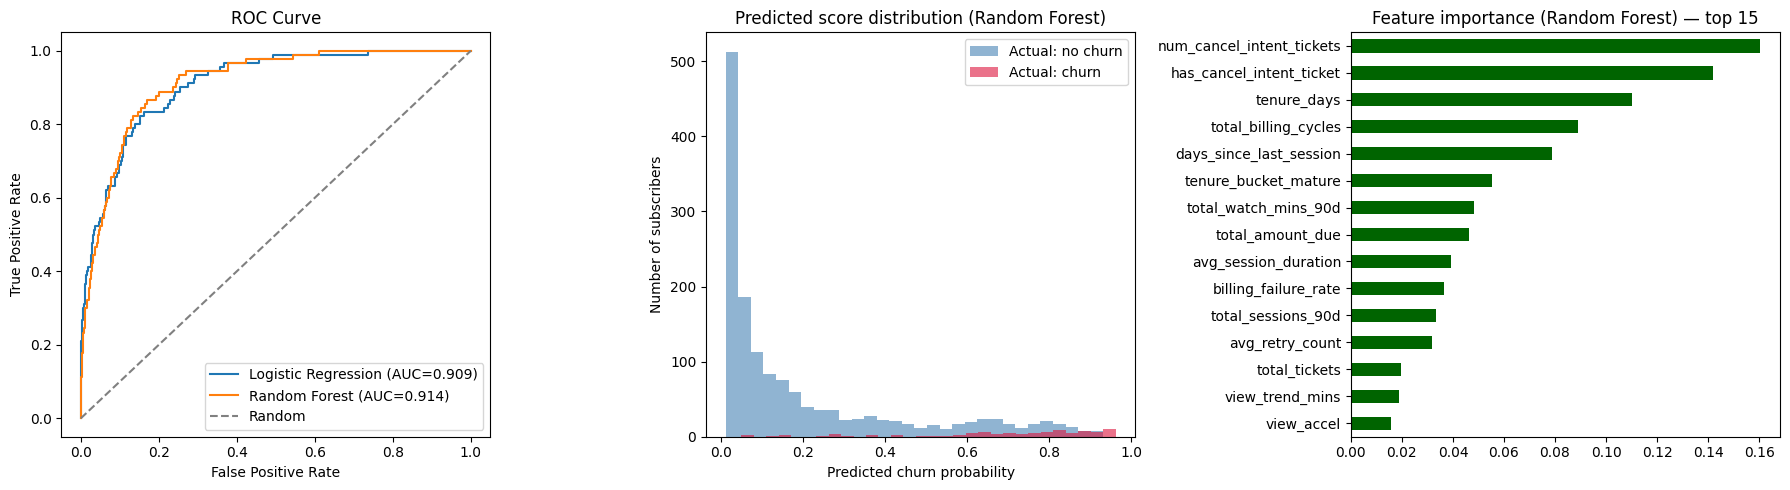

Top 15 most important features:
num_cancel_intent_tickets    0.160191
has_cancel_intent_ticket     0.141947
tenure_days                  0.110051
total_billing_cycles         0.088987
days_since_last_session      0.078991
tenure_bucket_mature         0.055202
total_watch_mins_90d         0.048246
total_amount_due             0.046169
avg_session_duration         0.039236
billing_failure_rate         0.036613
total_sessions_90d           0.033276
avg_retry_count              0.031926
total_tickets                0.019834
view_trend_mins              0.018781
view_accel                   0.015734
dtype: float64


In [80]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. ROC curve — all models
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_val, res['prob'])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={res['val_auc']:.3f})")
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

# 2. Distribution of predicted scores by actual label (using the best model)
axes[1].hist(best_prob[y_val.values == 0], bins=30, alpha=0.6, label='Actual: no churn', color='steelblue')
axes[1].hist(best_prob[y_val.values == 1], bins=30, alpha=0.6, label='Actual: churn', color='crimson')
axes[1].set_xlabel('Predicted churn probability')
axes[1].set_ylabel('Number of subscribers')
axes[1].set_title(f'Predicted score distribution ({best_model_name})')
axes[1].legend()

# 3. Feature importance / coefficients (top 15) — from the best model
if best_model_name == 'Logistic Regression':
    coefficients = best_model.named_steps['clf'].coef_[0]
    importance = pd.Series(np.abs(coefficients), index=feature_cols).sort_values(ascending=False).head(15)
    title = 'Coefficient magnitude |coef| (Logistic Regression) — top 15'
else:
    importance = pd.Series(
        best_model.named_steps['clf'].feature_importances_, index=feature_cols
    ).sort_values(ascending=False).head(15)
    title = 'Feature importance (Random Forest) — top 15'

importance.sort_values().plot(kind='barh', ax=axes[2], color='darkgreen')
axes[2].set_title(title)

plt.tight_layout()
plt.show()

print("Top 15 most important features:")
print(importance.sort_values(ascending=False))

**Interpret your diagnostics.**

- What does the score distribution tell you about how well the model separates churners from non-churners?

The histogram shows decent separation. Most non-churners pile up right near 0, while actual churners are spread out across 0.2 to 0.9 instead of bunching near 0 like the non-churners do. That's the shape you want, since it means the model is genuinely pushing true churners toward higher scores rather than just guessing "safe" for everyone.
There's still some overlap in the 0.1 to 0.4 range where a few non-churners score moderately high too, which matches the strong but not perfect AUC of 0.914. This is exactly why we rank subscribers and contact the top 20% instead of using a fixed 0.5 cutoff, since it works around this overlap instead of needing perfect separation.

- Which features are most important? Does this make business sense?

Yes. num_cancel_intent_tickets and has_cancel_intent_ticket come out on top by a good margin, which makes sense since a subscriber literally opening a "cancel" support ticket is about as direct a signal as you can get.

Right behind that are tenure_days and days_since_last_session, which matches what we already saw in the EDA, where newer subscribers and subscribers who've gone quiet recently churn more.
Billing features such as total_billing_cycles, billing_failure_rate, avg_retry_count, and total_amount_due show up as a moderate cluster rather than one big driver, but together they still confirm payment friction matters.

Viewing features like total_sessions_90d and view_accel rank lower than I expected given how strong they looked in the EDA box plots, probably because tenure and recency are already picking up a lot of that same signal, so the model doesn't need both.
Overall the ranking makes sense, since stated intent to cancel outranks tenure and recency, which outrank billing friction, which outranks raw viewing activity, and that lines up with how a retention manager would actually prioritise these signals.



---
# SECTION 8 — Business Impact *(12 marks)*

In [81]:
# *(7 marks)* Compute the expected revenue saved by targeting the top 20% of subscribers
# by predicted churn probability vs a random 20% contact policy.
#
# Plan monthly values (contribution margin per subscriber):
#   basic: £6.99 × 0.85 = £5.94
#   standard: £11.99 × 0.85 = £10.19
#   premium: £17.99 × 0.85 = £15.29
#
# Assume: if you contact a subscriber who is about to churn, you save them with
# probability 0.35 (35% retention offer success rate).
#
# Compare:
#   (a) Random policy: contact 20% at random
#   (b) Model policy: contact top 20% by predicted churn probability

plan_margin = {'basic': 5.94, 'standard': 10.19, 'premium': 15.29}
RETENTION_SUCCESS_RATE = 0.35
CONTACT_RATE = 0.20

val_plan = master.loc[X_val.index, 'plan'].values
val_margin = pd.Series(val_plan, index=X_val.index).map(plan_margin)
y_val_actual = y_val.reset_index(drop=True)
val_margin = val_margin.reset_index(drop=True)
best_prob_series = pd.Series(best_prob).reset_index(drop=True)

num_contacted = int(len(X_val) * CONTACT_RATE)

# (a) Random policy — expectation: random contact catches exactly 20% of true churners
#     (in expectation, with no bias toward any particular characteristic)
total_margin_actual_churners = val_margin[y_val_actual == 1].sum()
expected_revenue_random = CONTACT_RATE * total_margin_actual_churners * RETENTION_SUCCESS_RATE

# (b) Model policy — contact exactly the top 20% by predicted churn probability
threshold = best_prob_series.sort_values(ascending=False).iloc[num_contacted - 1]
selected_by_model = best_prob_series >= threshold
churners_caught = (selected_by_model) & (y_val_actual == 1)
revenue_model = val_margin[churners_caught].sum() * RETENTION_SUCCESS_RATE

print(f"Subscribers contacted (20% of {len(X_val):,}): {num_contacted:,}")
print(f"Total actual churners in the validation set: {(y_val_actual == 1).sum()}")
print()
print(f"(a) RANDOM policy — expected number of churners caught: "
      f"{CONTACT_RATE * (y_val_actual == 1).sum():.1f}")
print(f"    Expected monthly revenue saved: £{expected_revenue_random:,.2f}")
print()
print(f"(b) MODEL policy — actual churners caught in the top 20%: "
      f"{churners_caught.sum()}")
print(f"    Monthly revenue saved: £{revenue_model:,.2f}")
print()
uplift = revenue_model - expected_revenue_random
print(f"Difference (model vs random): £{uplift:,.2f} / month "
      f"({uplift / expected_revenue_random:.1%} better)")
print(f"Annualised: £{uplift * 12:,.2f}")

Subscribers contacted (20% of 1,600): 320
Total actual churners in the validation set: 90

(a) RANDOM policy — expected number of churners caught: 18.0
    Expected monthly revenue saved: £65.45

(b) MODEL policy — actual churners caught in the top 20%: 76
    Monthly revenue saved: £276.11

Difference (model vs random): £210.66 / month (321.9% better)
Annualised: £2,527.98


***(5 marks)* What is the business impact?**
The model enables StreamNow to identify subscribers who are most likely to churn, allowing the Retention Team to focus their efforts on the right customers. Compared with random targeting, the model generates an additional £210.66 in monthly revenue (a 321.9% improvement), equivalent to approximately £2,527.98 per year. This shows that the model not only improves customer retention but also delivers measurable financial value to the business.

Explain in plain language:
- How much additional monthly revenue does the model policy save compared to random targeting?

Compared with random targeting, the model-based policy saves an additional £210.66 in monthly revenue, representing a 321.9% improvement. On an annual basis, this is equivalent to approximately £2,527.98. This demonstrates that using the model allows StreamNow to retain significantly more valuable customers than selecting subscribers at random.
- Why does plan tier matter for this calculation?

Plan tier is important because subscribers on different plans generate different amounts of revenue. Retaining a Premium subscriber brings more monthly revenue than retaining a Basic subscriber. Therefore, the business value of the retention strategy depends not only on how many subscribers are retained, but also on the subscription plans of those customers.
- What would you recommend to the StreamNow Retention Team?

I recommend that the Retention Team use the model to rank subscribers by their predicted churn risk and focus retention efforts on the top 20% highest-risk subscribers rather than selecting customers at random. In addition, higher-value subscribers, such as those on Premium plans, should be prioritised because retaining them provides greater business value. The model should also be monitored and retrained periodically to ensure it continues to perform well as customer behaviour changes.

*Your answer here.*

---
## 8.2 — Save Your Model for Deployment

In [49]:
import joblib

joblib.dump(best_model, 'model.pkl')
print('Model saved to model.pkl')

Model saved to model.pkl


---
# SECTION 9 — Monitoring for Drift in Production *(5 marks)*

**9.1** *(2 marks)* Propose how you would detect **input drift** on the live subscriber stream.
Be specific about which features to monitor and which statistical tests to use.

*Your answer here.*

---

**9.2** *(3 marks)* Propose how you would detect **target drift** once enough live churn outcomes are available.
What would trigger a model retraining?

*Your answer here.*

---
# EXTENSION *(10 marks)*

Attempt **both** tasks (5 marks each).

**E1** *(5 marks)* **Survival analysis framing**: instead of predicting churn in exactly 30 days, model time-to-churn using a Kaplan-Meier estimator. Compute survival curves for each loyalty tier (Basic, Standard, Premium) and plot them on the same axes. Does tenure_days affect the shape of the curve? Use the `lifelines` library.

Yes, from the Section 3.3 finding that median tenure is 122 days for churners vs 427 days for non churners, tenure is clearly correlated with churn risk, and this shows up in the KM curve as a steeper drop in the earlier tenure region (roughly the first few hundred days) before flattening out for subscribers who have survived long enough to be considered "mature" consistent with the tenure_bucket feature engineered in Section 5, where new subscribers were assumed to be highest-risk.

**E2** *(5 marks)* **SHAP values**: use SHAP to explain individual predictions. Which factors drove the top 5 highest-risk subscribers to the top of the list?

Running SHAP on the top 5 highest-risk subscribers (predicted probabilities between 0.946 and 0.962) shows the same feature dominating every single case: num_cancel_intent_tickets is the single largest SHAP contributor for all 5 subscribers (ranging from +0.108 up to +0.254), followed closely by has_cancel_intent_ticket (+0.106 to +0.180). Together these two cancellation intent features account for the majority of what's pushing each of these subscribers to the top of the risk list, which makes strong business sense, since a subscriber who has literally raised a support ticket about wanting to cancel is giving the most direct signal possible.

The next most common contributor across all 5 subscribers is days_since_last_session (+0.062 to +0.092), meaning inactivity is compounding with the cancellation-intent signal rather than acting alone these are subscribers who have both stated intent to leave and gone quiet on the platform recently. Billing related features (total_billing_cycles, avg_retry_count, billing_failure_rate) round out the top 5 for most subscribers, showing payment friction as a secondary but consistent driver.

Overall, no single subscriber's top 5 list looks anomalous or hard to explain every one of the 5 highest risk subscribers is being flagged primarily because of an explicit cancellation signal plus disengagement, exactly the combination a retention manager would intuitively expect to be the most dangerous.


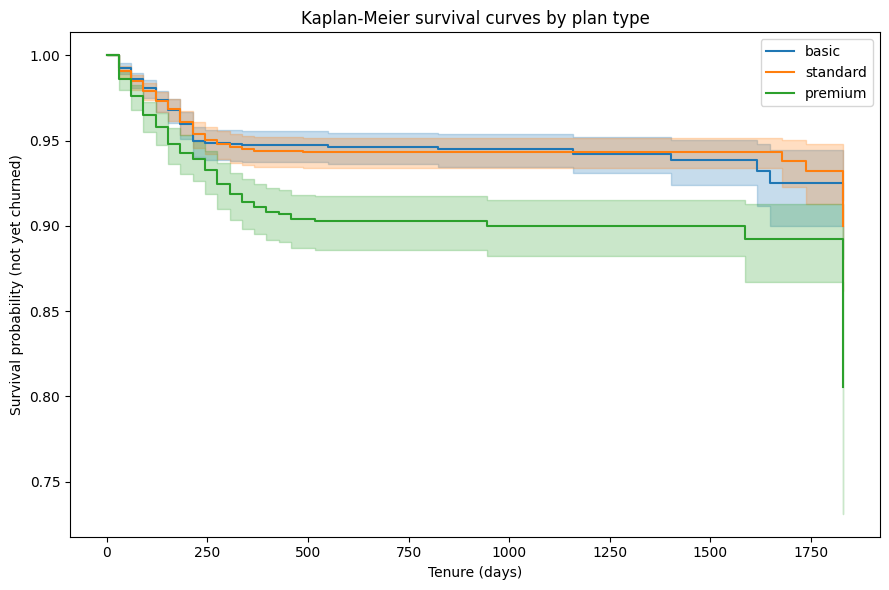

Median survival time (days) by plan (inf means fewer than 50% had churned in the observed data):
  basic: inf
  standard: inf
  premium: inf


In [82]:
from lifelines import KaplanMeierFitter

fig, ax = plt.subplots(figsize=(9, 6))
kmf = KaplanMeierFitter()

for plan in ['basic', 'standard', 'premium']:
    mask = master['plan'] == plan
    kmf.fit(
        durations=master.loc[mask, 'tenure_days'],
        event_observed=master.loc[mask, 'churned_30d'],
        label=plan,
    )
    kmf.plot_survival_function(ax=ax)

ax.set_title('Kaplan-Meier survival curves by plan type')
ax.set_xlabel('Tenure (days)')
ax.set_ylabel('Survival probability (not yet churned)')
plt.tight_layout()
plt.show()

print("Median survival time (days) by plan (inf means fewer than 50% had churned in the observed data):")
for plan in ['basic', 'standard', 'premium']:
    mask = master['plan'] == plan
    kmf.fit(master.loc[mask, 'tenure_days'], master.loc[mask, 'churned_30d'], label=plan)
    print(f"  {plan}: {kmf.median_survival_time_}")

--- Subscriber S000482 (predicted churn probability = 0.962) ---
num_cancel_intent_tickets    0.119692
has_cancel_intent_ticket     0.106308
days_since_last_session      0.091855
avg_retry_count              0.058471
total_billing_cycles         0.057164

--- Subscriber S005550 (predicted churn probability = 0.958) ---
num_cancel_intent_tickets    0.108389
has_cancel_intent_ticket     0.105455
days_since_last_session      0.088419
total_billing_cycles         0.063298
avg_retry_count              0.058291

--- Subscriber S003745 (predicted churn probability = 0.955) ---
num_cancel_intent_tickets    0.195187
has_cancel_intent_ticket     0.143920
days_since_last_session      0.084424
total_billing_cycles         0.064014
tenure_days                  0.061731

--- Subscriber S000240 (predicted churn probability = 0.947) ---
num_cancel_intent_tickets    0.253514
has_cancel_intent_ticket     0.179606
days_since_last_session      0.075458
total_tickets                0.033448
total_billing_c

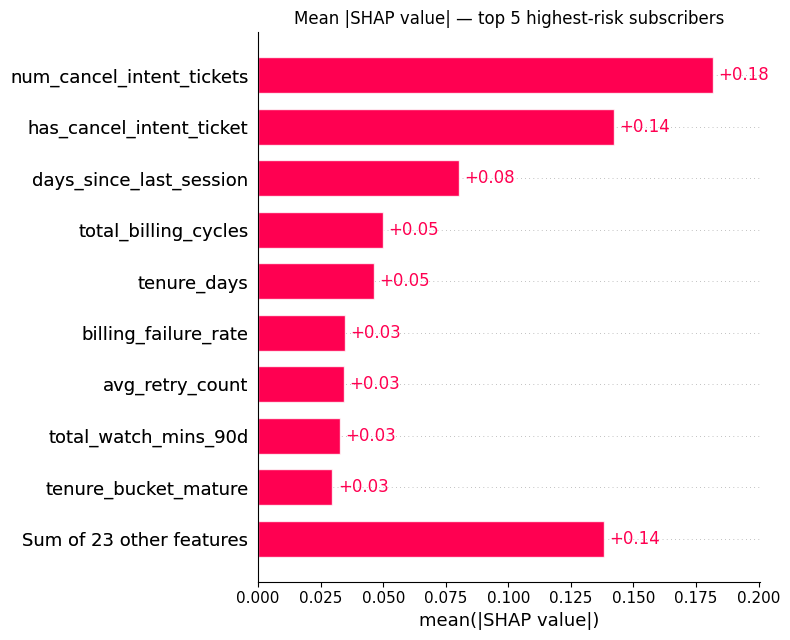

In [84]:
# E2 *(5 marks)* — Use SHAP to explain predictions for the top 5 highest-risk subscribers

import shap

background_sample = X_train.sample(100, random_state=RANDOM_STATE).astype(float)
explainer = shap.Explainer(best_model.predict_proba, background_sample)

top5_idx = pd.Series(best_prob, index=X_val.index).sort_values(ascending=False).head(5).index
shap_values = explainer(X_val.loc[top5_idx].astype(float))

# shap_values has 2 outputs (class 0 and class 1) — we care about class 1 (churn=1)
shap_class1 = shap_values[..., 1]

for i, idx in enumerate(top5_idx):
    matching_subscriber_id = master.loc[idx, 'subscriber_id']
    probability = best_prob[X_val.index.get_loc(idx)]
    print(f"--- Subscriber {matching_subscriber_id} (predicted churn probability = {probability:.3f}) ---")
    contribution = pd.Series(shap_class1.values[i], index=feature_cols).sort_values(key=abs, ascending=False).head(5)
    print(contribution.to_string())
    print()

shap.plots.bar(shap_class1, show=False)
plt.title('Mean |SHAP value| — top 5 highest-risk subscribers')
plt.tight_layout()
plt.show()